In [7]:
import os
import latan
import numpy as np
import latan.datasets.arXiv_2508_11541 as lf_paper
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"


In [4]:
os.chdir(os.path.dirname(os.path.abspath("__file__")))
filename = lf_paper.download(".")

Done!


In [6]:
data = lf_paper.load_correlator(filename, "F1M-mes-lh", verbose=True)
data = lf_paper.bin_correlator(data, 24, verbose=True)
n = data.shape[0]
nt = data.shape[1]

nConf: 72
 nSrc: 48
   nt: 96
 size: 3456
 nBin: 144


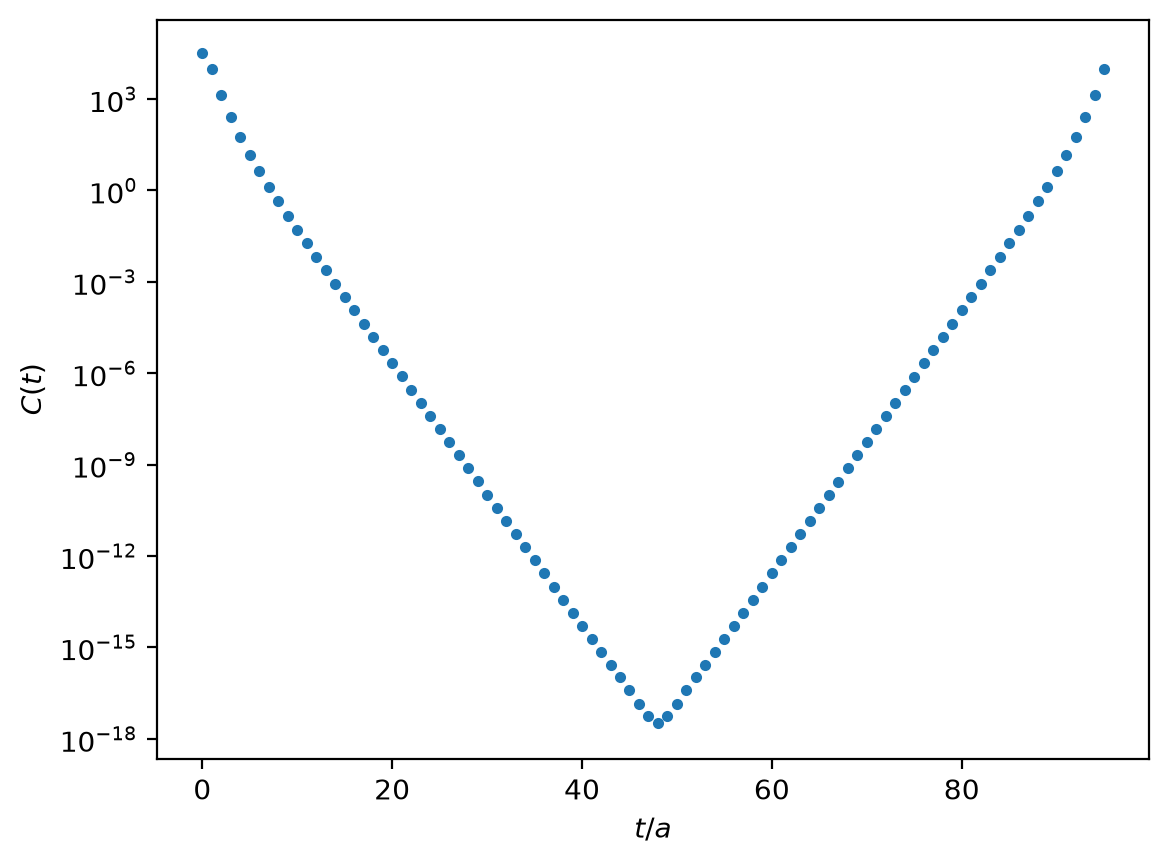

In [8]:
plt.errorbar(np.arange(nt), data.mean(axis=0), data.std(axis=0) / np.sqrt(n), fmt=".")
plt.yscale("log")
plt.xlabel(r"$t/a$")
plt.ylabel(r"$C(t)$")
plt.show()

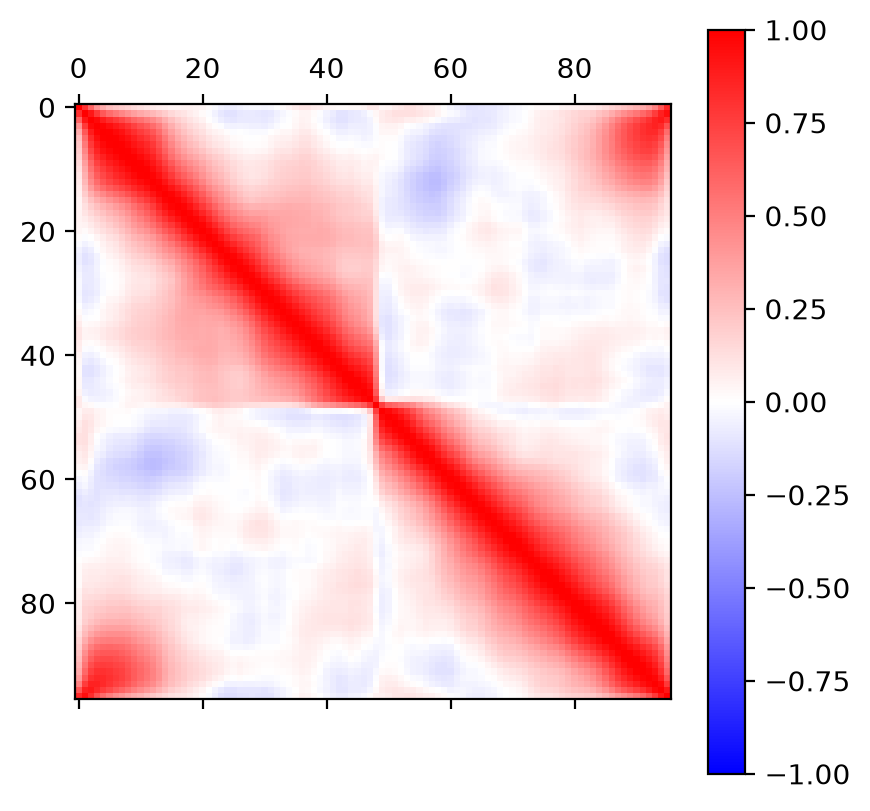

CDR = 55.62 dB


In [9]:
V = np.cov(data, rowvar=False) / n
Gamma, err = latan.var_to_corr(V)
plt.matshow(Gamma, cmap="bwr", vmin=-1.0, vmax=1.0)
plt.colorbar()
plt.show()
print(f"CDR = {latan.cdr(Gamma):.2f} dB")